In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.tree import plot_tree 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("house_price_decision_tree_regression_30_records.csv")

In [3]:
df.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Floors,Parking,Distance_City_km,Crime_Rate,Location_Score,Price_Lakhs
0,800,2,1,15,1,0,8.5,7.2,5,25
1,900,2,1,12,1,1,7.2,6.5,6,29
2,1000,2,2,10,1,1,6.5,6.0,6,33
3,1100,2,2,8,2,1,6.0,5.5,7,37
4,1200,3,2,10,2,1,5.5,5.2,7,41


In [4]:
df.tail()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Floors,Parking,Distance_City_km,Crime_Rate,Location_Score,Price_Lakhs
25,3600,6,6,2,3,3,1.2,1.5,10,148
26,3800,6,6,1,3,3,1.1,1.4,10,160
27,4000,7,6,2,4,3,1.0,1.3,10,175
28,4200,7,6,1,4,3,0.9,1.2,10,190
29,4500,7,7,1,4,3,0.8,1.0,10,210


In [5]:
df.shape

(30, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Area_sqft         30 non-null     int64  
 1   Bedrooms          30 non-null     int64  
 2   Bathrooms         30 non-null     int64  
 3   Age_years         30 non-null     int64  
 4   Floors            30 non-null     int64  
 5   Parking           30 non-null     int64  
 6   Distance_City_km  30 non-null     float64
 7   Crime_Rate        30 non-null     float64
 8   Location_Score    30 non-null     int64  
 9   Price_Lakhs       30 non-null     int64  
dtypes: float64(2), int64(8)
memory usage: 2.5 KB


In [7]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Floors,Parking,Distance_City_km,Crime_Rate,Location_Score,Price_Lakhs
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.00000,30.000000
mean,2346.666667,4.333333,3.800000,4.266667,2.533333,1.866667,3.066667,3.146667,8.80000,92.100000
std,1034.485824,1.538771,1.606023,3.522669,0.819307,0.776079,2.023710,1.688038,1.47157,49.242083
min,800.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.800000,1.000000,5.00000,25.000000
25%,1525.000000,3.000000,3.000000,2.000000,2.000000,1.000000,1.550000,1.825000,8.00000,54.000000
50%,2250.000000,4.000000,4.000000,3.000000,3.000000,2.000000,2.450000,2.750000,9.00000,84.000000
75%,2975.000000,5.000000,5.000000,5.000000,3.000000,2.000000,3.950000,4.150000,10.00000,118.250000
max,4500.000000,7.000000,7.000000,15.000000,4.000000,3.000000,8.500000,7.200000,10.00000,210.000000


In [8]:

df.isnull()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Floors,Parking,Distance_City_km,Crime_Rate,Location_Score,Price_Lakhs
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False


In [9]:
df.duplicated

<bound method DataFrame.duplicated of     Area_sqft  Bedrooms  Bathrooms  Age_years  Floors  Parking  \
0         800         2          1         15       1        0   
1         900         2          1         12       1        1   
2        1000         2          2         10       1        1   
3        1100         2          2          8       2        1   
4        1200         3          2         10       2        1   
5        1300         3          2          7       2        1   
6        1400         3          2          6       2        1   
7        1500         3          3          5       2        1   
8        1600         3          3          4       2        1   
9        1700         3          3          3       2        2   
10       1800         4          3          5       2        2   
11       1900         4          3          4       2        2   
12       2000         4          3          3       2        2   
13       2100         4          3    

In [10]:
df.duplicated

<bound method DataFrame.duplicated of     Area_sqft  Bedrooms  Bathrooms  Age_years  Floors  Parking  \
0         800         2          1         15       1        0   
1         900         2          1         12       1        1   
2        1000         2          2         10       1        1   
3        1100         2          2          8       2        1   
4        1200         3          2         10       2        1   
5        1300         3          2          7       2        1   
6        1400         3          2          6       2        1   
7        1500         3          3          5       2        1   
8        1600         3          3          4       2        1   
9        1700         3          3          3       2        2   
10       1800         4          3          5       2        2   
11       1900         4          3          4       2        2   
12       2000         4          3          3       2        2   
13       2100         4          3    

In [11]:
x = df.drop('Price_Lakhs', axis=1)
x

,Area_sqft,Bedrooms,Bathrooms,Age_years,Floors,Parking,Distance_City_km,Crime_Rate,Location_Score
0,800,2,1,15,1,0,8.5,7.2,5
1,900,2,1,12,1,1,7.2,6.5,6
2,1000,2,2,10,1,1,6.5,6.0,6
3,1100,2,2,8,2,1,6.0,5.5,7
4,1200,3,2,10,2,1,5.5,5.2,7
5,1300,3,2,7,2,1,5.0,4.8,7
6,1400,3,2,6,2,1,4.5,4.5,8
7,1500,3,3,5,2,1,4.0,4.2,8
8,1600,3,3,4,2,1,3.8,4.0,8
9,1700,3,3,3,2,2,3.5,3.8,8


In [12]:
y = df[["Price_Lakhs"]]
y

,Price_Lakhs
0,25
1,29
2,33
3,37
4,41
5,45
6,49
7,53
8,57
9,61


In [13]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
Xtrain

,Area_sqft,Bedrooms,Bathrooms,Age_years,Floors,Parking,Distance_City_km,Crime_Rate,Location_Score
28,4200,7,6,1,4,3,0.9,1.2,10
24,3400,6,5,2,3,3,1.3,1.6,10
12,2000,4,3,3,2,2,2.8,3.0,9
0,800,2,1,15,1,0,8.5,7.2,5
4,1200,3,2,10,2,1,5.5,5.2,7
16,2400,5,4,3,3,2,2.2,2.5,10
5,1300,3,2,7,2,1,5.0,4.8,7
13,2100,4,3,4,2,2,2.7,2.9,9
11,1900,4,3,4,2,2,3.0,3.2,9
22,3000,5,5,1,3,2,1.5,1.8,10


In [15]:
Xtest

,Area_sqft,Bedrooms,Bathrooms,Age_years,Floors,Parking,Distance_City_km,Crime_Rate,Location_Score
27,4000,7,6,2,4,3,1.0,1.3,10
15,2300,4,4,3,3,2,2.4,2.7,9
23,3200,6,5,3,3,2,1.4,1.7,10
17,2500,5,4,2,3,2,2.1,2.4,10
8,1600,3,3,4,2,1,3.8,4.0,8
9,1700,3,3,3,2,2,3.5,3.8,8


In [16]:
Ytrain

,Price_Lakhs
28,190
24,138
12,75
0,25
4,41
16,90
5,45
13,79
11,70
22,120


In [17]:
Ytest

,Price_Lakhs
27,175
15,86
23,128
17,94
8,57
9,61


In [18]:
model = DecisionTreeRegressor(max_depth=3)
model.fit(Xtrain, Ytrain)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with 

In [19]:
y_pred = model.predict(Xtest)
y_pred

array([200. ,  74.4, 143. ,  94. ,  47. ,  47. ])

In [20]:
print("Mean Squared Error : ", mean_squared_error(Ytest, y_pred))

Mean Squared Error :  213.42666666666665


In [21]:
print("RMSE = ", np.sqrt(mean_squared_error(Ytest, y_pred)))

RMSE =  14.609129565674563


In [22]:
print("R2 Score : ", r2_score(Ytest, y_pred))

R2 Score :  0.8720825772080246


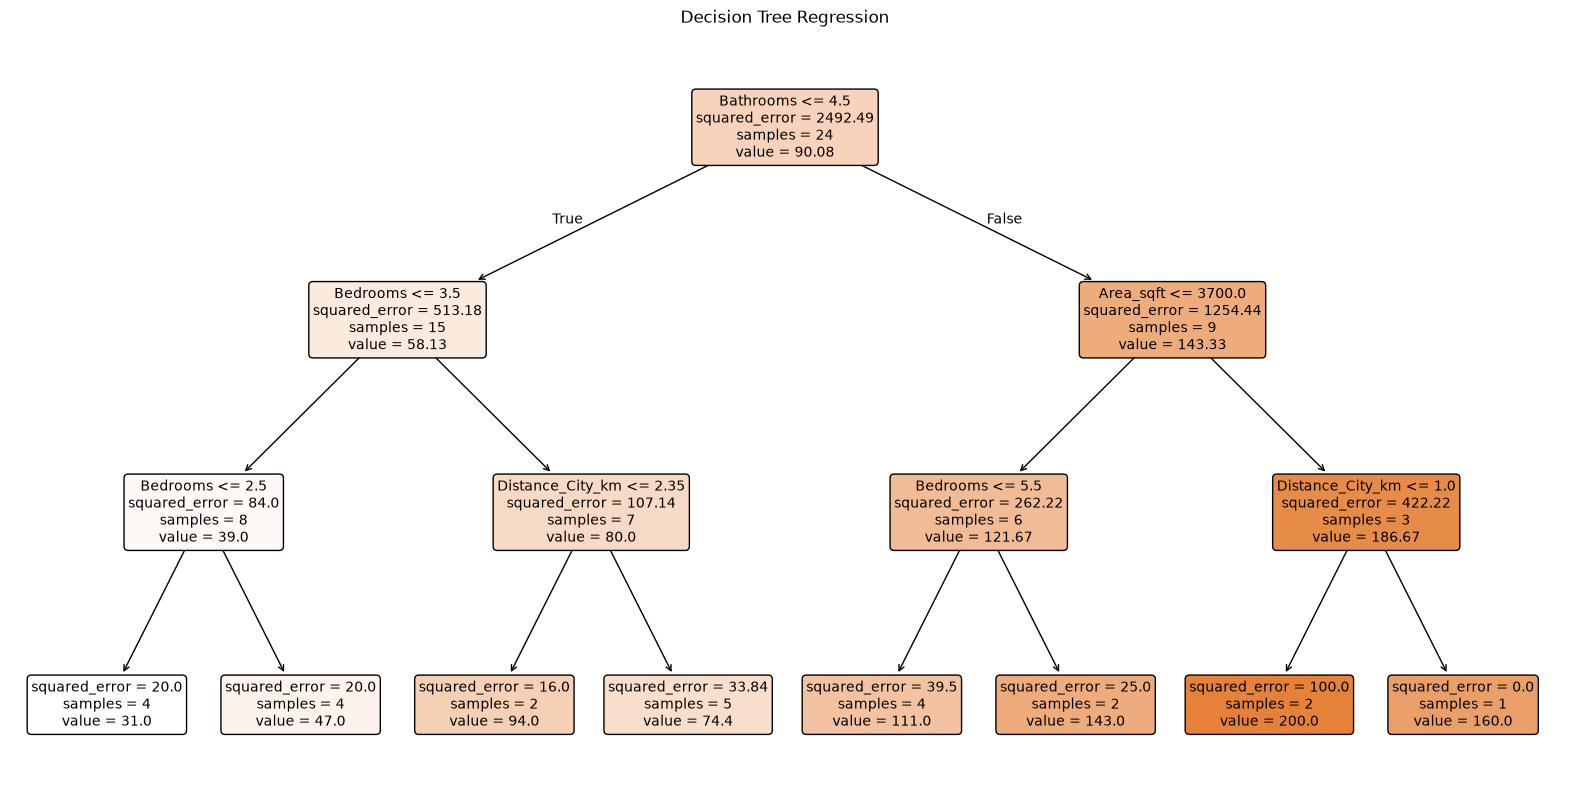

In [23]:
plt.figure(figsize=(20, 10))

plot_tree(model, feature_names=x.columns, filled=True, rounded=True, precision=2)

plt.title("Decision Tree Regression")

plt.show()

In [24]:
import sys
print(sys.executable)

c:\Python314\python.exe


In [25]:
%pip install scikit-learn pandas matplotlib numpy

Note: you may need to restart the kernel to use updated packages.
